In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -U scikit-posthocs

In [3]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Forecast')

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils.plot_dashes as plot_dashes
import scikit_posthocs as sp

from scipy.stats import friedmanchisquare
from conf.processing import DataProcessing
from utils import genetic_algorithm as gen_alg
from models import ann_models, kernel_method, tree_based_ensemble as tree_based

pd.set_option('display.float_format', '{:.6f}'.format)

Dataset

In [50]:
all_results = []
all_runs = []
ga_runs = []

def get_file():

    file_path = '/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets'

    for f in os.listdir(file_path):
        full_path = os.path.join(file_path, f)

        yield full_path

for f in get_file():

    dataset = pd.read_csv(f, sep='\t', decimal='.')
    raw_data = DataProcessing(dataset, n_lags=5)
    prep_data = raw_data.prepare_data()

    mlp = ann_models.MLP()
    results_MLP = mlp.train(prep_data)
    MLP_forecast_v = np.array(results_MLP['pred_valid'])
    MLP_forecast = np.array(results_MLP['pred_test_denom'])
    
    scn = ann_models.GridSCN()
    results_SCN = scn.train(prep_data)
    SCN_forecast_v = np.array(results_SCN['pred_valid'])
    SCN_forecast = np.array(results_SCN['pred_test'])

    elm = ann_models.GridELM()
    results_ELM = elm.train(prep_data)
    ELM_forecast_v = np.array(results_ELM['pred_valid'])
    ELM_forecast = np.array(results_ELM['pred_test_denom'])

    svr = kernel_method.SVM()
    results_SVR = svr.train(prep_data)
    SVR_forecast_v = np.array(results_SVR['pred_valid'])
    SVR_forecast = np.array(results_SVR['pred_test'])
    
    rf = tree_based.RF()
    results_RF = rf.train(prep_data)
    RF_forecast_v = np.array(results_RF['pred_valid'])
    RF_forecast = np.array(results_RF['pred_test'])

    gb = tree_based.GBoosting()
    results_GB = gb.train(prep_data)
    GB_forecast_v = np.array(results_GB['pred_valid'])
    GB_forecast = np.array(results_GB['pred_test'])

    P_v = np.column_stack(
        (
            MLP_forecast_v.copy(), 
            SCN_forecast_v.copy(),
            ELM_forecast_v.copy(), 
            SVR_forecast_v.copy(), 
            RF_forecast_v.copy(), 
            GB_forecast_v.copy()
        )
    )

    P = np.column_stack(
        (
            MLP_forecast.copy(), 
            SCN_forecast.copy(),
            ELM_forecast.copy(), 
            SVR_forecast.copy(), 
            RF_forecast.copy(), 
            GB_forecast.copy()
        )
    )
    
    for x in range(10):
        
        ga = gen_alg.GeneticAlgorithm()
        
        ga_result = ga.execute(P_v, prep_data['target_valid'])

        y_hat = P @ ga_result['best_ind']
        ga_metrics = plot_dashes.get_metrics_error(prep_data['target_test'], y_hat)
        ga_runs.append({

            'Dataset': os.path.basename(f),
            'Run': x,

            'MSE': ga_metrics['MSE'],
            'RMSE': ga_metrics['RMSE'],
            'MAE': ga_metrics['MAE'],
            'MAPE': ga_metrics['MAPE'],

            'Weights': ga_result['best_ind'],
            'Fitness': ga_result['best_fitness'],
            'Fitness_Curve': ga_result['fitness_curve']

        })
    
    
    ensemble_mean = np.mean(P, axis=1)

    MLP = plot_dashes.get_metrics_error(prep_data['target_test'], MLP_forecast)
    SCN = plot_dashes.get_metrics_error(prep_data['target_test'], SCN_forecast)
    ELM = plot_dashes.get_metrics_error(prep_data['target_test'], ELM_forecast)
    SVR = plot_dashes.get_metrics_error(prep_data['target_test'], SVR_forecast)
    RF = plot_dashes.get_metrics_error(prep_data['target_test'], RF_forecast)
    GB = plot_dashes.get_metrics_error(prep_data['target_test'], GB_forecast)
    EMEAN = plot_dashes.get_metrics_error(prep_data['target_test'], ensemble_mean)
    GA = plot_dashes.get_metrics_error(prep_data['target_test'], y_hat)

    all_results.append({
        'dataset': os.path.basename(f),
        'MLP': MLP,
        'SCN': SCN,
        'ELM': ELM,
        'SVR': SVR,
        'RF': RF,
        'GB': GB,
        'EMEAN': EMEAN,
        'GA': GA
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'MLP',
        'runs': results_MLP['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'SCN',
        'runs': results_SCN['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'ELM',
        'runs': results_ELM['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'SVR',
        'runs': results_SVR['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'RF',
        'runs': results_RF['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'GB',
        'runs': results_GB['lst_results']
    })
    

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [51]:
df_results = pd.DataFrame(all_results)
df_runs = pd.DataFrame(all_runs)

In [52]:
# 1. Tabela Principal (MSE, RMSE, MAE e MAPE)
rows = []

for _, row in df_results.iterrows():

    dataset = row['dataset']

    for model in ['MLP','SCN','ELM','SVR','RF','GB', 'EMEAN', 'GA']:
        metrics = row[model]
        rows.append({

            'Dataset': dataset,
            'Model': model,

            'MSE': metrics['MSE'],
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MAPE': metrics['MAPE']

        })

df_metrics = pd.DataFrame(rows)

In [53]:
df_metrics

,Dataset,Model,MSE,RMSE,MAE,MAPE
0,airlines.txt,MLP,3677.685524,60.643924,46.947457,0.099546
1,airlines.txt,SCN,8387.601724,91.583851,76.767984,0.164909
2,airlines.txt,ELM,7261.676459,85.215471,67.402473,0.155710
3,airlines.txt,SVR,15222.424587,123.379190,105.387674,0.222434
4,airlines.txt,RF,22154.295907,148.843192,127.779707,0.269653
5,airlines.txt,GB,20154.553053,141.966732,120.217282,0.252672
6,airlines.txt,EMEAN,10002.879750,100.014398,84.580588,0.178508
7,airlines.txt,GA,5528.684577,74.355125,60.547366,0.128586
8,coloradoRiver.txt,MLP,0.297891,0.545794,0.407296,1.312045
9,coloradoRiver.txt,SCN,0.398398,0.631188,0.459072,0.974092


In [9]:
# 2. Média das Métricas por Modelo
df_metrics.groupby('Model')[['MSE','RMSE','MAE','MAPE']].mean()

,MSE,RMSE,MAE,MAPE
Model,,,,
ELM,183620.770176,246.641594,180.058030,0.662275
EMEAN,146017.810603,216.684157,169.814131,0.483090
GA,138395.222542,204.687749,160.873348,0.510596
GB,213095.889385,264.281201,216.764766,0.676636
MLP,139184.519131,201.782364,152.773564,0.592510
RF,163754.746141,236.826305,182.850561,0.433501
SCN,139865.831843,206.469082,158.424795,0.666913
SVR,407780.949493,349.343362,264.713658,0.451048


In [10]:
# 3. Ranking dos Modelos
ranking = []

for dataset in df_metrics['Dataset'].unique():

    temp = df_metrics[df_metrics['Dataset']==dataset]
    temp = temp.sort_values('MSE')
    temp['Rank'] = range(1,len(temp)+1)
    ranking.append(temp)

df_rank = pd.concat(ranking)

In [11]:
df_rank

,Dataset,Model,MSE,RMSE,MAE,MAPE,Rank
0,airlines.txt,MLP,3677.685524,60.643924,46.947457,0.099546,1
7,airlines.txt,GA,5750.412999,75.831478,61.795015,0.131528,2
1,airlines.txt,SCN,6277.426346,79.230211,65.833874,0.146766,3
6,airlines.txt,EMEAN,11513.127048,107.299241,91.156334,0.193161,4
3,airlines.txt,SVR,15222.424587,123.379190,105.387674,0.222434,5
2,airlines.txt,ELM,19028.682639,137.944491,109.956103,0.246176,6
5,airlines.txt,GB,20154.553053,141.966732,120.217282,0.252672,7
4,airlines.txt,RF,22154.295907,148.843192,127.779707,0.269653,8
10,coloradoRiver.txt,ELM,0.266960,0.516682,0.265837,0.357704,1
14,coloradoRiver.txt,EMEAN,0.278477,0.527710,0.351390,0.730723,2


In [12]:
df_rank.groupby('Model')['Rank'].mean()

,Rank
Model,
ELM,4.750000
EMEAN,2.750000
GA,2.000000
GB,7.000000
MLP,3.500000
RF,6.250000
SCN,4.000000
SVR,5.750000


In [13]:
# 4. Média e Desvio das Execuções - Valores NaN

rows=[]

for _,row in df_runs.iterrows():

    for i,mse in enumerate(row['runs']):

        rows.append({

            'Dataset':row['dataset'],
            'Model':row['model'],
            'Run':i,
            'MSE':mse

        })

df_runs_expand = pd.DataFrame(rows)

df_runs_expand.groupby(
    ['Dataset','Model']
)['MSE'].agg(
    ['mean','std','min','max']
)

mean          std            min  \
Dataset           Model                                              
airlines.txt      ELM     18480.327003   471.949388   18114.756579   
                  GB      20172.847557    38.575053   20154.553053   
                  MLP      4045.443629  1093.692864    3677.685524   
                  RF      22549.442353   540.641534   22154.295907   
                  SCN      6277.426346          NaN    6277.426346   
                  SVR     15222.424587          NaN   15222.424587   
coloradoRiver.txt ELM         0.265864     0.001422       0.264103   
                  GB          0.374943     0.000000       0.374943   
                  MLP         0.318504     0.029437       0.277628   
                  RF          0.482189     0.013456       0.477933   
                  SCN         0.413241          NaN       0.413241   
                  SVR         0.315603          NaN       0.315603   
lynx.txt          ELM    651469.036308 67440.813695  587489.062749   
                  GB     832734.800840  1078.090296  832223.417711   
                  MLP    557553.219704 28530.463384  507075.470156   
                  RF     683606.410090 50378.316588  632859.165130   
                  SCN    553180.460081          NaN  553180.460081   
                  SVR   1615895.979524          NaN 1615895.979524   
melbmin.txt       ELM         5.121236     0.000000       5.121236   
                  GB          5.212669     0.001766       5.211832   
                  MLP         5.100387     0.022292       5.079239   
                  RF          5.045595     0.000000       5.045595   
                  SCN         5.027702          NaN       5.027702   
                  SVR         5.078260          NaN       5.078260   

                                   max  
Dataset           Model                 
airlines.txt      ELM     19028.682639  
                  GB      20247.567894  
                  MLP      7152.880000  
                  RF      23652.130469  
                  SCN      6277.426346  
                  SVR     15222.424587  
coloradoRiver.txt ELM         0.266960  
                  GB          0.374943  
                  MLP         0.351731  
                  RF          0.520486  
                  SCN         0.413241  
                  SVR         0.315603  
lynx.txt          ELM    715449.009867  
                  GB     834780.333355  
                  MLP    587937.584708  
                  RF     740547.933896  
                  SCN    553180.460081  
                  SVR   1615895.979524  
melbmin.txt       ELM         5.121236  
                  GB          5.216019  
                  MLP         5.121536  
                  RF          5.045595  
                  SCN         5.027702  
                  SVR         5.078260

In [14]:
# 5. Organizar o GA

ga_runs.append({

    'Dataset':os.path.basename(f),
    'Run':x,
    'MSE':metrics['MSE'],
    'RMSE':metrics['RMSE'],
    'MAE':metrics['MAE'],
    'MAPE':metrics['MAPE'],
    'Weights':ga_result['best_ind'],
    'Fitness':ga_result['best_fitness']

})

df_ga = pd.DataFrame(ga_runs)

In [15]:
df_ga.groupby('Dataset')['MSE'].mean()

,MSE
Dataset,
airlines.txt,6670.860857
coloradoRiver.txt,0.281229
lynx.txt,543266.346616
melbmin.txt,5.023027


In [16]:
df_ga.groupby('Dataset')['MSE'].std()

,MSE
Dataset,
airlines.txt,699.252171
coloradoRiver.txt,0.005133
lynx.txt,4291.805957
melbmin.txt,0.007334


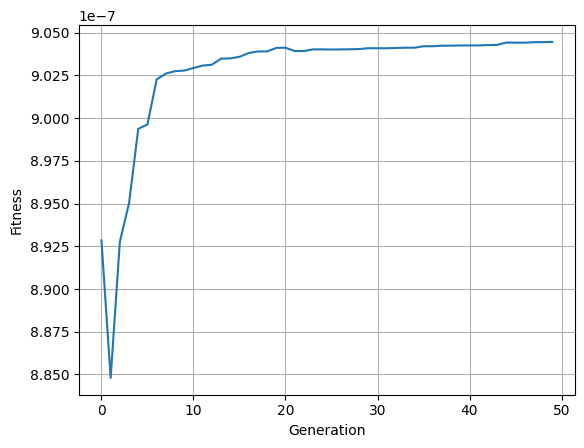

In [18]:
# 7. Curva de Convergência

ga_result['fitness_curve']
plt.plot(ga_result['fitness_curve'])
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.grid()
plt.show()

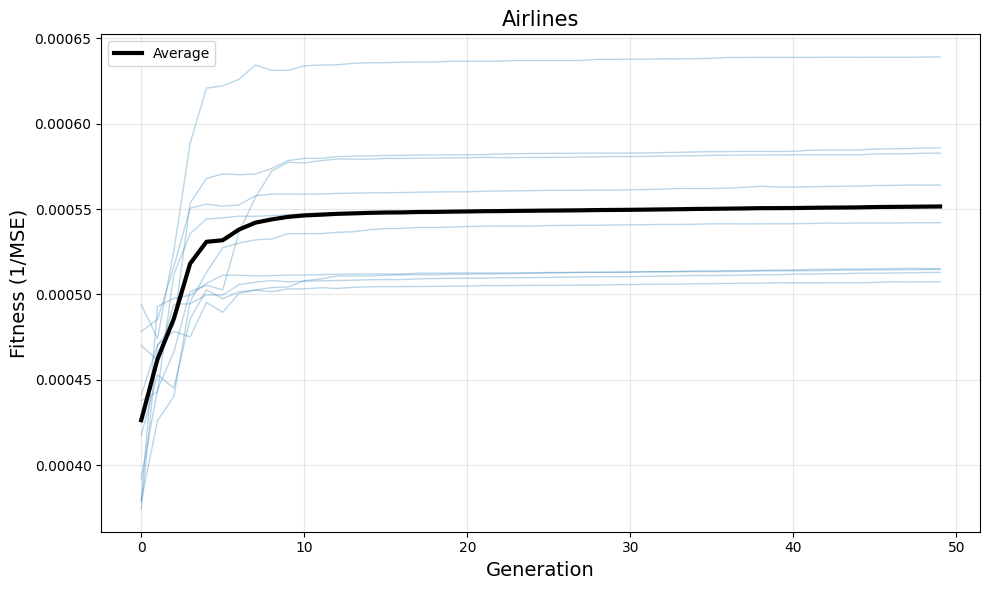

In [67]:
# Curvas de fitness airlines
dataset = "airlines.txt"

fitness_curves = np.array([
    run["Fitness_Curve"]
    for run in ga_runs
    if run["Dataset"] == dataset
])

# Média por geração
mean_curve = fitness_curves.mean(axis=0)

plt.figure(figsize=(10, 6))

# Cada execução (linhas azuis)
for curve in fitness_curves:
    plt.plot(curve,
             color='tab:blue',
             alpha=0.30,
             linewidth=1)

# Média (linha preta)
plt.plot(mean_curve,
         color='black',
         linewidth=3,
         label='Average')

plt.xlabel("Generation", fontsize=14)
plt.title("Airlines", fontsize=15)
plt.ylabel("Fitness (1/MSE)", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

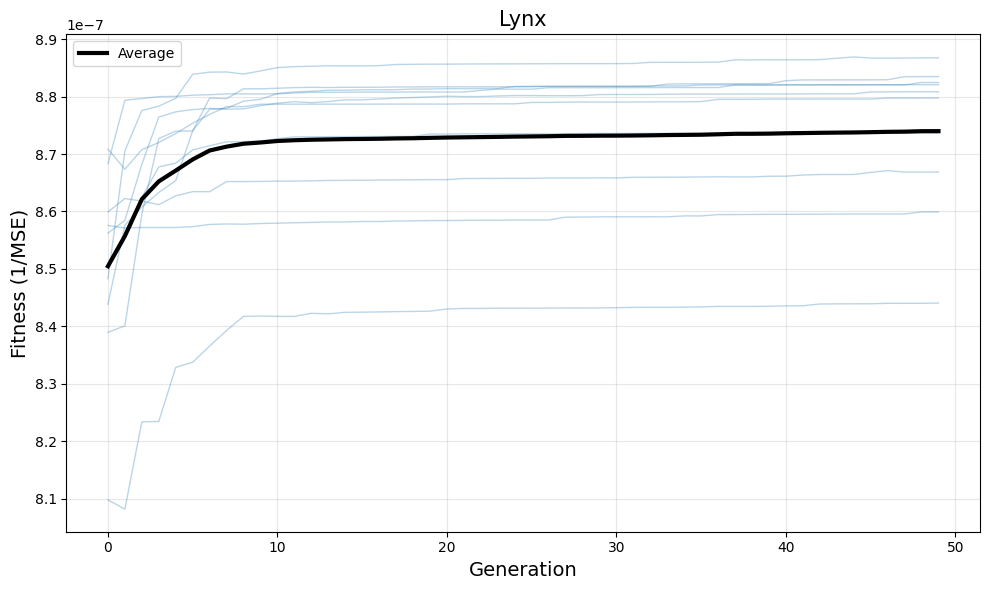

In [68]:
# Curvas de fitness Lynx
dataset = "lynx.txt"

fitness_curves = np.array([
    run["Fitness_Curve"]
    for run in ga_runs
    if run["Dataset"] == dataset
])

# Média por geração
mean_curve = fitness_curves.mean(axis=0)

plt.figure(figsize=(10, 6))

# Cada execução (linhas azuis)
for curve in fitness_curves:
    plt.plot(curve,
             color='tab:blue',
             alpha=0.30,
             linewidth=1)

# Média (linha preta)
plt.plot(mean_curve,
         color='black',
         linewidth=3,
         label='Average')

plt.xlabel("Generation", fontsize=14)
plt.title("Lynx", fontsize=15)
plt.ylabel("Fitness (1/MSE)", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

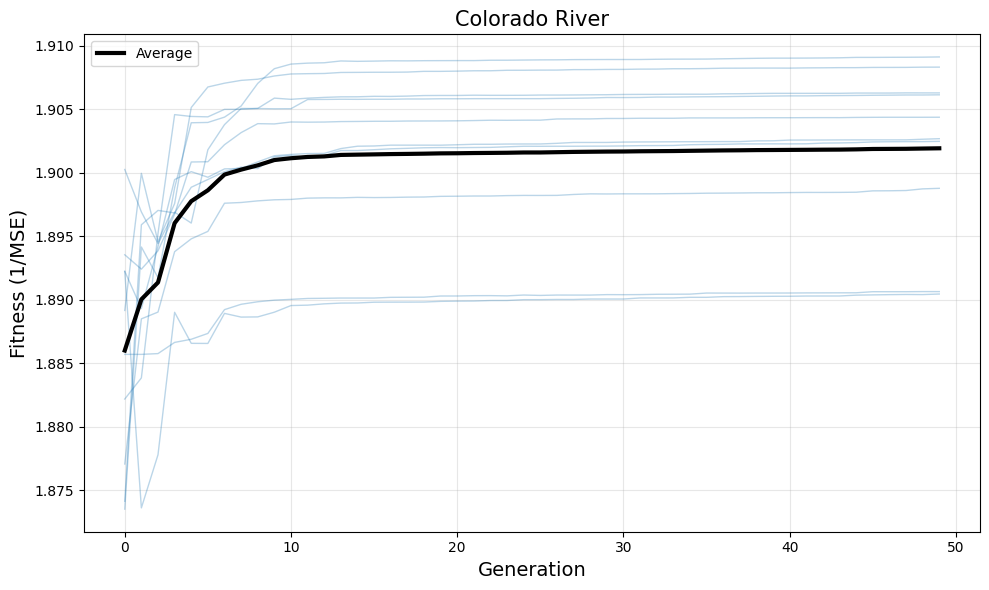

In [71]:
# Curvas de fitness coloradoRiver
dataset = "coloradoRiver.txt"

fitness_curves = np.array([
    run["Fitness_Curve"]
    for run in ga_runs
    if run["Dataset"] == dataset
])

# Média por geração
mean_curve = fitness_curves.mean(axis=0)

plt.figure(figsize=(10, 6))

# Cada execução (linhas azuis)
for curve in fitness_curves:
    plt.plot(curve,
             color='tab:blue',
             alpha=0.30,
             linewidth=1)

# Média (linha preta)
plt.plot(mean_curve,
         color='black',
         linewidth=3,
         label='Average')

plt.xlabel("Generation", fontsize=14)
plt.title("Colorado River", fontsize=15)
plt.ylabel("Fitness (1/MSE)", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

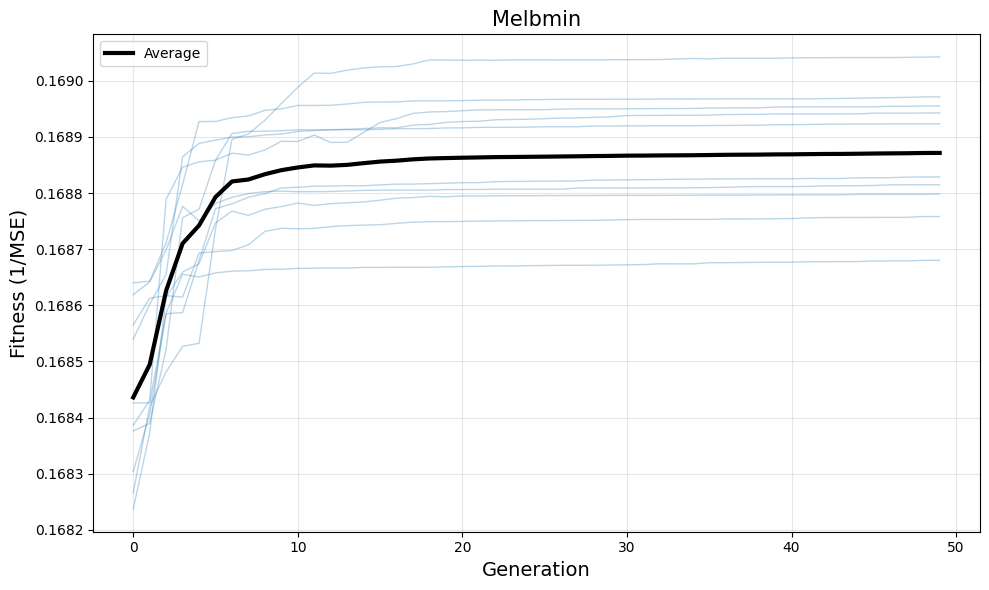

In [72]:
# Curvas de fitness melbmin
dataset = "melbmin.txt"

fitness_curves = np.array([
    run["Fitness_Curve"]
    for run in ga_runs
    if run["Dataset"] == dataset
])

# Média por geração
mean_curve = fitness_curves.mean(axis=0)

plt.figure(figsize=(10, 6))

# Cada execução (linhas azuis)
for curve in fitness_curves:
    plt.plot(curve,
             color='tab:blue',
             alpha=0.30,
             linewidth=1)

# Média (linha preta)
plt.plot(mean_curve,
         color='black',
         linewidth=3,
         label='Average')

plt.xlabel("Generation", fontsize=14)
plt.title("Melbmin", fontsize=15)
plt.ylabel("Fitness (1/MSE)", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

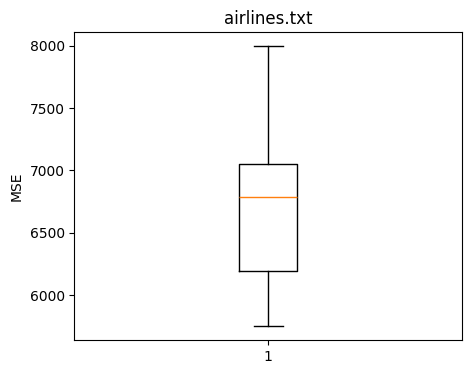

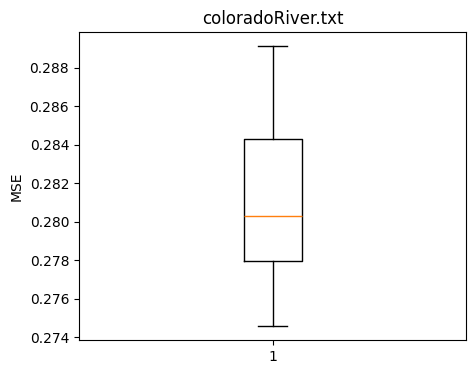

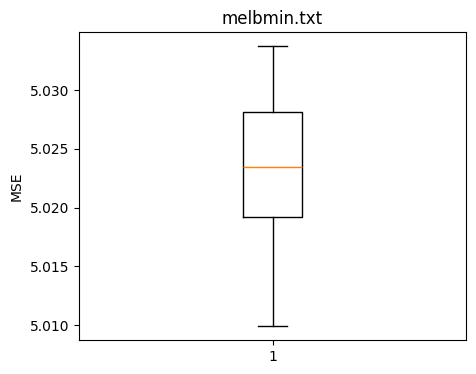

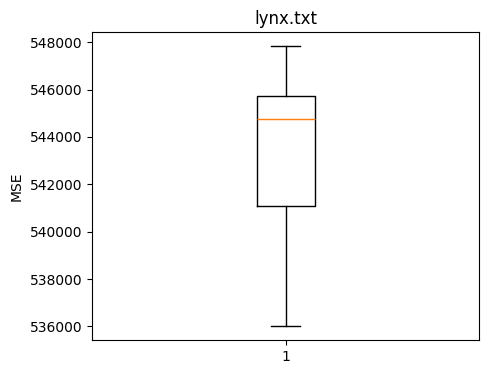

In [19]:
# Boxplot de Dispersão

for dataset in df_ga['Dataset'].unique():
    plt.figure(figsize=(5,4))
    dados = df_ga[df_ga['Dataset']==dataset]['MSE']
    plt.boxplot(dados)
    plt.title(dataset)
    plt.ylabel("MSE")
    plt.show()

In [20]:
# Friedman

friedman_df = df_metrics.pivot(
    index='Dataset',
    columns='Model',
    values='MSE'

)

In [21]:
friedman_df

Model,ELM,EMEAN,GA,GB,MLP,RF,SCN,SVR
Dataset,,,,,,,,
airlines.txt,19028.682639,11513.127048,5750.412999,20154.553053,3677.685524,22154.295907,6277.426346,15222.424587
coloradoRiver.txt,0.266960,0.278477,0.279943,0.374943,0.297891,0.477933,0.413241,0.315603
lynx.txt,715449.009867,572552.830614,547825.187311,832223.417711,553054.971571,632859.165130,553180.460081,1615895.979524
melbmin.txt,5.121236,5.006273,5.009916,5.211832,5.121536,5.045595,5.027702,5.078260


In [23]:
friedmanchisquare(

friedman_df['MLP'],
friedman_df['SCN'],
friedman_df['ELM'],
friedman_df['SVR'],
friedman_df['RF'],
friedman_df['GB'],
friedman_df['EMEAN'],
friedman_df['GA']
)

FriedmanchisquareResult(statistic=np.float64(14.333333333333329), pvalue=np.float64(0.04556053530040479))

In [24]:
nemenyi = sp.posthoc_nemenyi_friedman(
    friedman_df.values
)
nemenyi.index = friedman_df.columns
nemenyi.columns = friedman_df.columns

In [25]:
nemenyi

Model,ELM,EMEAN,GA,GB,MLP,RF,SCN,SVR
Model,,,,,,,,
ELM,1.000000,0.944413,0.757943,0.899562,0.996387,0.988970,0.999872,0.999135
EMEAN,0.944413,1.000000,0.999872,0.215662,0.999872,0.467650,0.996387,0.666146
GA,0.757943,0.999872,1.000000,0.075228,0.988970,0.215662,0.944413,0.373136
GB,0.899562,0.215662,0.075228,1.000000,0.467650,0.999872,0.666146,0.996387
MLP,0.996387,0.999872,0.988970,0.467650,1.000000,0.757943,0.999992,0.899562
RF,0.988970,0.467650,0.215662,0.999872,0.757943,1.000000,0.899562,0.999992
SCN,0.999872,0.996387,0.944413,0.666146,0.999992,0.899562,1.000000,0.973060
SVR,0.999135,0.666146,0.373136,0.996387,0.899562,0.999992,0.973060,1.000000


In [26]:
ranks = friedman_df.rank(axis=1, ascending=True)
avg_ranks = ranks.mean(axis=0)
avg_ranks

,0
Model,
ELM,4.750000
EMEAN,2.750000
GA,2.000000
GB,7.000000
MLP,3.500000
RF,6.250000
SCN,4.000000
SVR,5.750000


{'markers': [<matplotlib.collections.PathCollection at 0x7fcae4d3bb00>,
 'elbows': [<matplotlib.lines.Line2D at 0x7fcae4d3a720>,
 'labels': [Text(1.99, -2, 'GA (2)'),
  Text(1.99, -3, 'EMEAN (2.8)'),
  Text(1.99, -4, 'MLP (3.5)'),
  Text(1.99, -5, 'SCN (4)'),
  Text(7.01, -2, '(7) GB'),
  Text(7.01, -3, '(6.2) RF'),
  Text(7.01, -4, '(5.8) SVR'),
  Text(7.01, -5, '(4.8) ELM')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x7fcae4d385f0>]]}

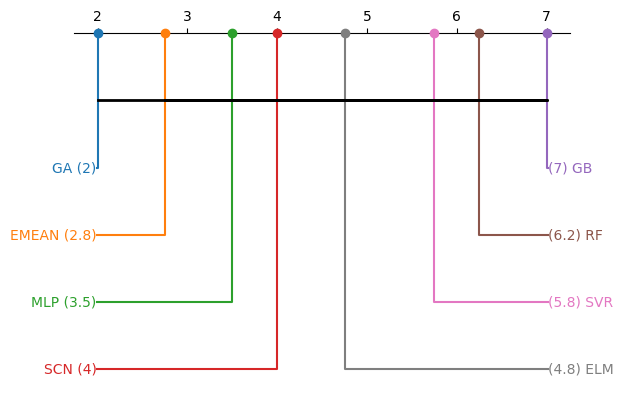

In [27]:
from scikit_posthocs import critical_difference_diagram

critical_difference_diagram(
    avg_ranks,
    nemenyi
)

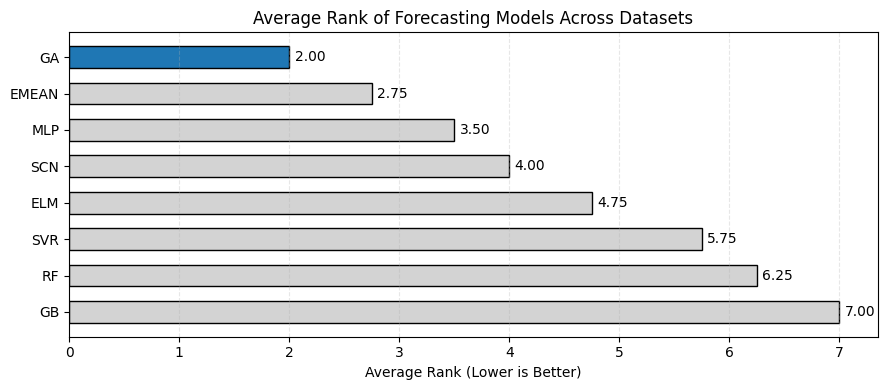

In [28]:
avg_rank = (
    df_rank
    .groupby('Model')['Rank']
    .mean()
    .sort_values()
)

# Todos com Cinza
colors = ['lightgray'] * len(avg_rank)

# GA destaque
ga_idx = avg_rank.index.get_loc('GA')
colors[ga_idx] = 'tab:blue'

fig, ax = plt.subplots(figsize=(9,4))

bars = ax.barh(
    avg_rank.index,
    avg_rank.values,
    color=colors,
    edgecolor='black',
    height=0.6
)

ax.invert_yaxis()

ax.set_xlabel("Average Rank (Lower is Better)")
ax.set_title("Average Rank of Forecasting Models Across Datasets")

ax.grid(axis='x', linestyle='--', alpha=0.3)

for bar in bars:
    ax.text(
        bar.get_width()+0.05,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va='center'
    )

plt.tight_layout()
plt.show()